In [1]:
# LightGBM Regressor 실습

In [95]:
# 1. import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL.ImageColor import colormap
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score
# 매트릭 뭐썼냐? 하면 바로바로 나와줘야 함.

from lightgbm import LGBMRegressor

In [97]:
housing.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [96]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [22]:
# 2. 데이터 가져오기 (캘리포니아 집값)
housing = fetch_california_housing()

# 입력 변수 : features ( 평균 소득, 방 개수, 등등 ) <-- 독립 변수
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# 타겟 변수 : 집값 <-- 종속변수
y = pd.Series(housing.target, name="target" )

X.shape

(20640, 8)

In [6]:
X.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24


In [5]:
# 3. 데이터 전처리
print("\n [결측치 확인]")
print(X.isnull().sum())


 [결측치 확인]
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [56]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [76]:
# 4. 모델 생성 및 학습 ( LightGBM 모델 )
model = LGBMRegressor(
    n_estimators=300, #많을수록 복잡한 모델이 되는 것. 복잡한 게 좋은 건 아님.
    n_jobs=-1,
    learning_rate=0.05, # 학습률
    max_depth=-1, # 트리 최대 깊이 제한 없음
    num_leaves=31, # leaf 개수
    subsample=0.8,  # 과적합방지를 위해서 데이터 샘플링 비율을 0.8
    colsample_bytree=0.8, # feature 샘플링 비율 (과적합 방지)
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train) # 기존모델은 레벨 wise 단위 -> LGBM은 leaf-wise 방식을 학습

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000597 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [77]:
# 5. 예측 수행

# 테스트데이터에 대해 예측
y_pred = model.predict(X_test)

In [78]:
# 6. 성능 평가
# 회귀모형 이기 때문에 MAE, RMSE 로 예측값 실제값 차이 보고
# R2 로는 설명력 보기 (1에 가까울 수록 좋음)
#MAE
mae = mean_absolute_error(y_test, y_pred)

#RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2 <- 모델 설명력 (1 가까울 수록 좋음)
r2 = r2_score(y_test, y_pred)

# 결과 출력
print("\n [LightGBM 성능]")
print(f"MAE : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2 : {r2:.4f}")


 [LightGBM 성능]
MAE : 0.2953
RMSE : 0.4465
R2 : 0.8478


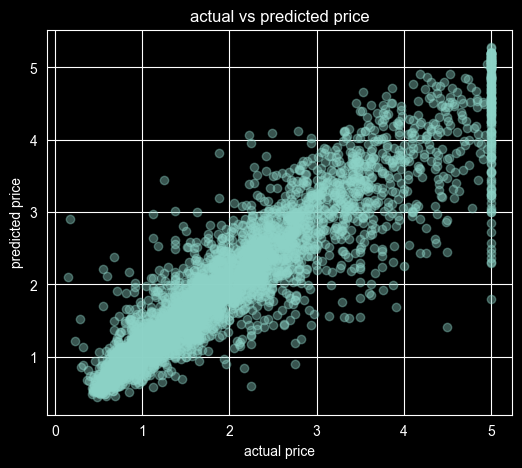

In [79]:
# 7. 성능 시각화
plt.figure(figsize = (6,5))
plt.scatter(y_test,y_pred, alpha = 0.4)

plt.xlabel("actual price")
plt.ylabel("predicted price")

plt.title("actual vs predicted price")
plt.show()

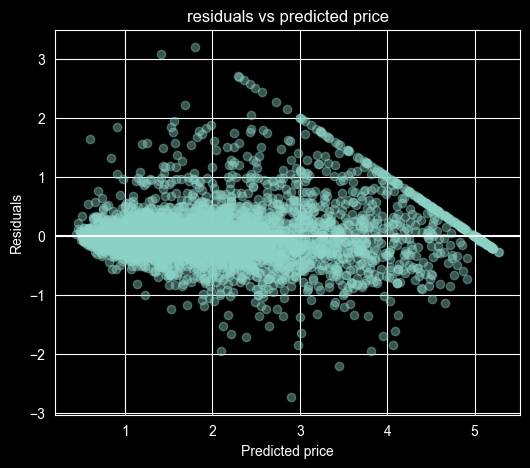

In [80]:
# 잔차가 어느정도 나타나고 있는지 확인해보자.
residuals = y_test -y_pred
plt.figure(figsize=(6,5))
plt.scatter(y_pred,residuals, alpha = 0.4)

# 기준선 (오차 0)
plt.axhline(0)
plt.xlabel("Predicted price")
plt.ylabel("Residuals")
plt.title("residuals vs predicted price")
plt.show()

오차가 있긴 있지만 허용 범위 내에 있다고 볼 수 있다.

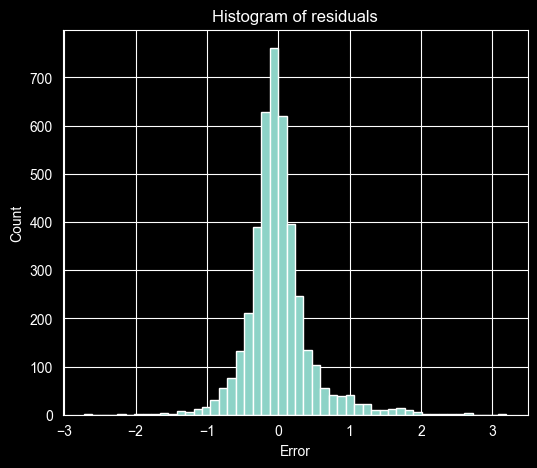

In [81]:
plt.figure(figsize=(6,5))
plt.hist(residuals, bins = 50)
plt.xlabel("Error")
plt.ylabel("Count")
plt.title("Histogram of residuals")
# plt.title("residual distribution")
plt.show()

학습한놈 결과가 이정도면 잘나왔다. 라고 볼 수 있음.

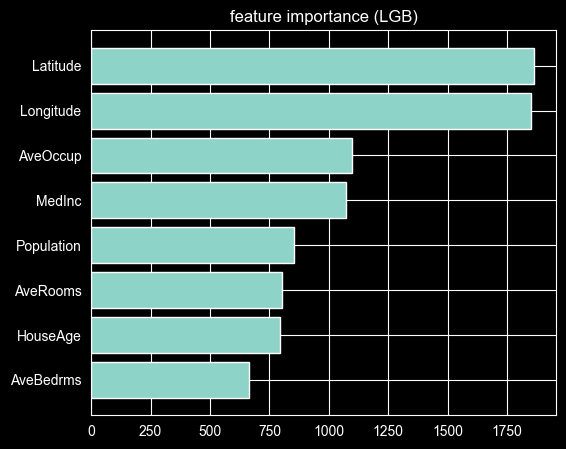

In [82]:
# 8. Feature Importance
# 가능하다면 샵을 쓰자.
importance = model.feature_importances_

# 중요도 정렬
indices = np.argsort(importance)

plt.figure(figsize=(6,5))

plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), X.columns[indices])

plt.title("feature importance (LGB)")
plt.show()

예측하고 원인까지 보여줄 수 있음.
그 이후 가장 좋은 건 자동보정 하는 게 좋음. --> 담당자한테 액션 조치 하든. 원인 나타나지 않게 설비 자동보정해서 자동 튜닝되는 게 가장 베스트지만 현업담당자들한테 알려주는 것만 해도 큰 도움이 됨.

원인 진단에도 도움됨.

In [83]:
# 9. 모델 예측
sample_data = X_test.iloc[:5] # 받아올 때 어떻게 받아와야 할까? -> 원래는 통신 통해서 가져온다

# 예측 수행
sample_pred = model.predict(sample_data)

print("[샘플 예측 결과]")
for i,pred in enumerate(sample_pred):
    print(f"{i} : {pred}")

print("\n[실제값]")
print(y_test.iloc[:5].values)

[샘플 예측 결과]
0 : 0.5710065007753734
1 : 0.9475801961348569
2 : 4.9756986538306505
3 : 2.4496870233540315
4 : 2.5211776305276565

[실제값]
[0.477   0.458   5.00001 2.186   2.78   ]


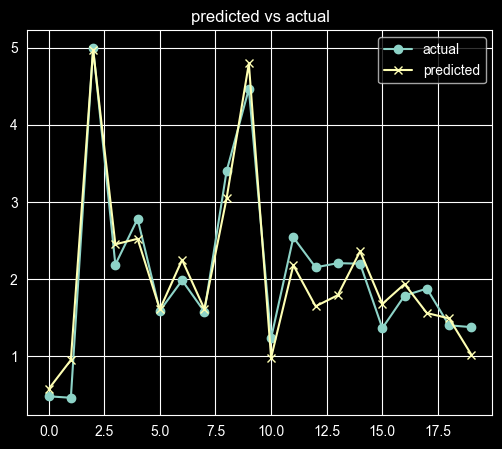

In [84]:
# 10. 예측 결과 시각화
plt.figure(figsize=(6,5))
plt.plot(y_test.iloc[:20].values, label = "actual", marker = "o") #실제 값
plt.plot(model.predict(X_test.iloc[:20]), label = "predicted", marker = "x")

plt.title("predicted vs actual")
plt.legend()
plt.show()

모델의 성능이 잘 나오지 않았을 경우...
위에서부터 순서대로 진행

1. 모델 튜닝해서 정확도 올라가는지
2. 데이터 늘리고
3. 피쳐 다시 선정해야 함.


단순 AI 모델로만 예측하기는 힘들고, rule - base 와 결합해서 해석 & 예측 결과 나와줘야 함.

---

# 앙상블 모델

각 모델 별로 예측 결과가 어떻게 나왔고, 그 예측 결과를 뽑아서 나온 결과를 확인해보자.

In [86]:
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [87]:
# 2. iris 데이터 로드 및 학습데이터 분할

iris = load_iris()
X = iris.data # X data
y = iris.target # y data
class_names = iris.target_names

X_train, X_test, y_train,y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)



In [88]:
# 개별 모델 정의 (svm, KNN, RandomForest)

# SVM
svm_clf = make_pipeline( #make pipeline  : 입력값의 StandardScaler 적용과 함께 모델을 파이프라인으로 묶어 사용
    StandardScaler(),
    SVC(
        C=1.0,
        kernel='rbf',
        probability=True,
        random_state=42
    )
)

# KNN
knn_clf = make_pipeline( #make pipeline  : 입력값의 StandardScaler 적용과 함께 모델을 파이프라인으로 묶어 사용
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

# RandomForest

rf_clf = RandomForestClassifier(
    # 위에 모델과 달리 트리기반 분류 모델이다보니까 구조가 달라서 안 태웠고, 태워도 상관 없다.
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# 3개 모델을 soft voting 방식으로 결합한 voting classifier
voting_clf = VotingClassifier(
    estimators=[('svm', svm_clf), ('knn', knn_clf), ('rf', rf_clf)],
    voting = 'soft', # 각 모델의 예측 확률값을 평균내서 최종 예측을 만듦
    weights= [1,1,2] # 특별히 random forest 모델의 가중치를 더 주는 것. (랜덤 포레스트 예측 결과 비중 높임)
)

In [89]:
# 모델 학습(fit)

svm_clf.fit(X_train, y_train)
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
voting_clf.fit(X_train, y_train)

,estimators,"[('svm', ...), ('knn', ...), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'


In [90]:
# 모델 평가 및 정확도 출력
y_pred = voting_clf.predict(X_test) # 테스트 데이터를 넣어 앙상블 모델로 예측 결과 출력
accuracy = accuracy_score(y_test, y_pred)

print("voting classifier accuracy : ", accuracy)

voting classifier accuracy :  0.9


분류모델은 평가 모델을 confusion matrix 씀.

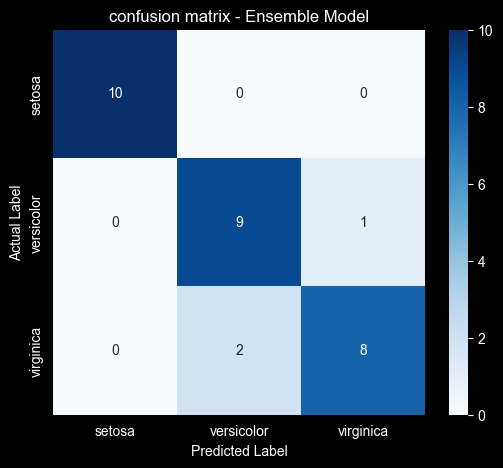

In [91]:
# confusion matrix 시각화
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6,5))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("confusion matrix - Ensemble Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()



C:\Users\human\AppData\Local\Temp\ipykernel_14884\973333623.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_f1, x = "class", y = "f1_score", palette = "viridis")


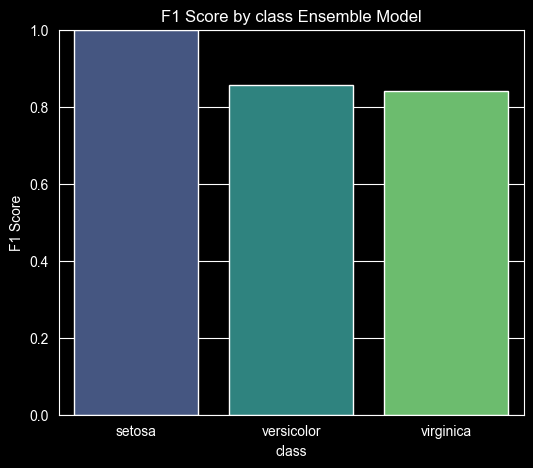

In [93]:
# classification
report = classification_report(
    y_test, y_pred,
    target_names=class_names,
    output_dict=True # dict 형태로 받아와서 dataframe 으로 시각화 출력
)

# 클래스 별 f1-score만 리스트로 받아옴
f1_score = [report[c]['f1-score'] for c in class_names]
df_f1 = pd.DataFrame({"class": class_names, "f1_score": f1_score})

plt.figure(figsize = (6,5))
sns.barplot(data = df_f1, x = "class", y = "f1_score", palette = "viridis")

plt.title("F1 Score by class Ensemble Model")
plt.ylabel('F1 Score')
plt.ylim([0,1]) # 이게 뭐냐면..
plt.show()

In [ ]:
# 1 ~ 2 개 틀리면 0.9~0.8 정도 나옴

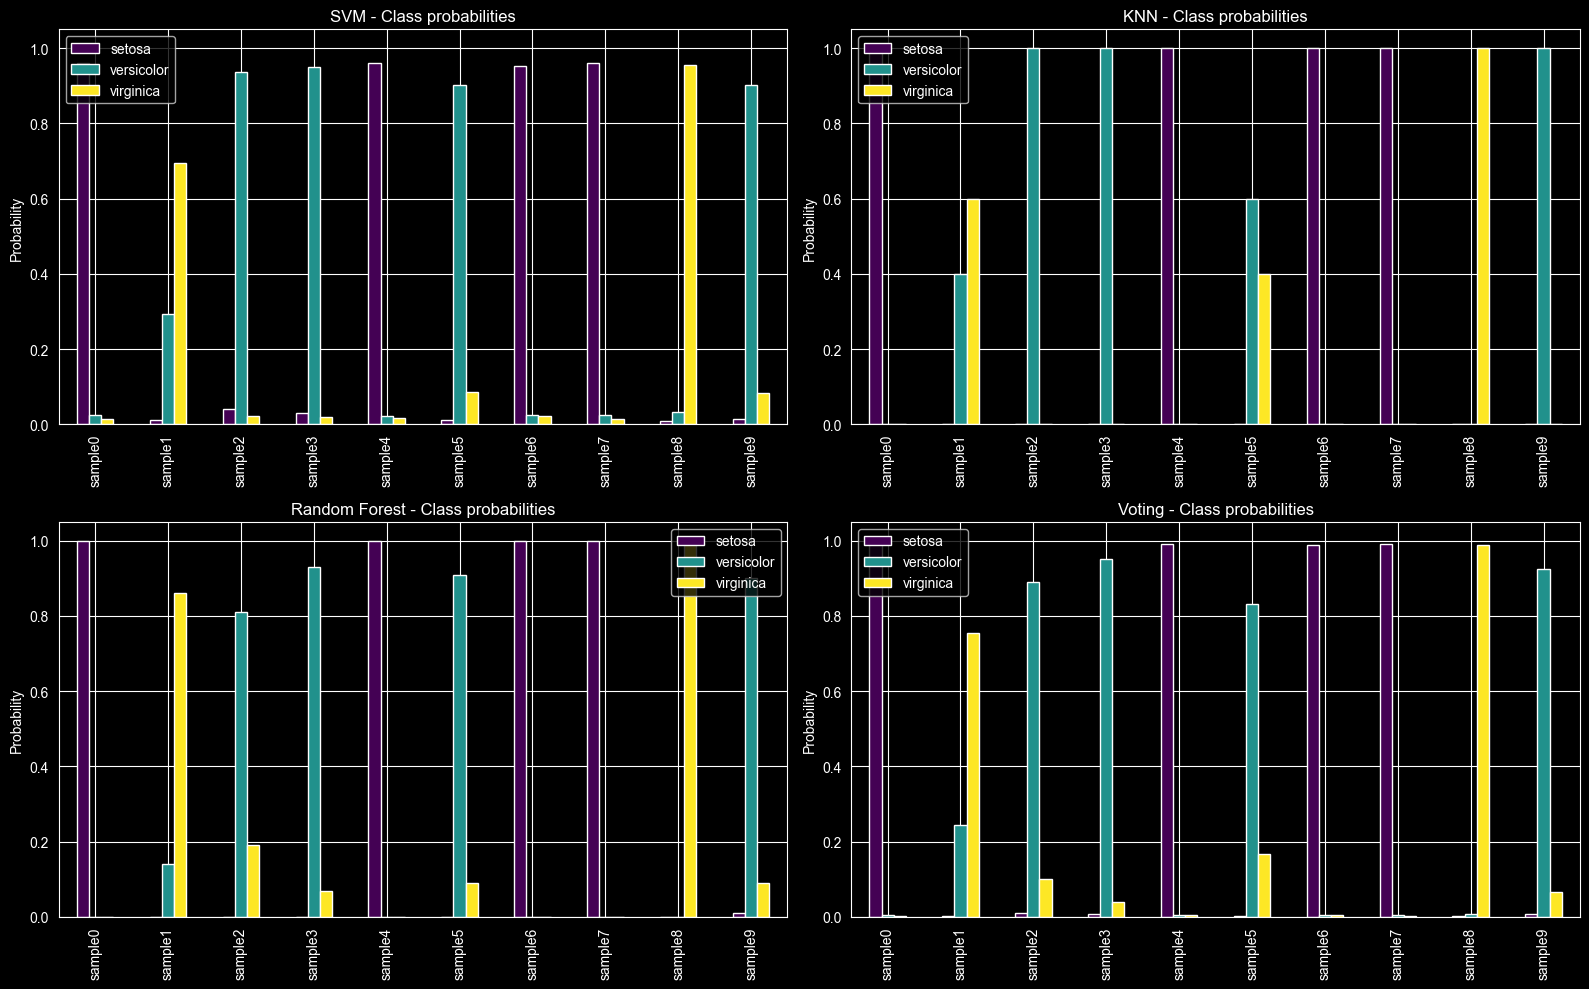

In [94]:
# 모델별 예측 활률 시각화
idx = np.arange(10) # 10개 샘플 인덱스 생성
X_sample = X_test[idx]
y_sample = y_test[idx]

proba_svm = svm_clf.predict_proba(X_sample) # svm의 예측 확률
proba_knn = knn_clf.predict_proba(X_sample) # knn의 예측 확률
proba_rf = rf_clf.predict_proba(X_sample) # rf의 예측 확률
proba_vote = voting_clf.predict_proba(X_sample) # voting의 예측 확률


model_names = ["SVM","KNN","Random Forest","Voting"]
proba_list = [proba_svm, proba_knn, proba_rf, proba_vote]

plt.figure(figsize = (16,10))

for i, (model_name, proba) in enumerate (zip(model_names, proba_list)):
    plt.subplot(2,2,i+1)
    df_prob = pd.DataFrame(proba, columns = class_names)
    df_prob.index = [f'sample{i}' for i in range(len(df_prob))]

    df_prob.plot(kind="bar", ax=plt.gca(), colormap='viridis')
    plt.ylabel("Probability")
    plt.ylim(0,1.05)
    plt.title(f'{model_name} - Class probabilities')
    plt.tight_layout()

plt.show()

모델마다 예측 결과가 차이가 많이 남.

각 모델 별 분류 잘 하는 특정 클래스들이 다 있음. 얘네들 상호 보완하는 앙상블 쓰는 것.
A모델이 클래스 1,2,3 잘 예측한다면 1,2,3 예측할 때 점수 주고, A모델이 잘 못하는 클래스 예측하려고 하면 패널티 주는 방식.

# 머신러닝

머신러닝은 데이터를 통해서 입력과 출력 사이 관게를 학습하는 과정.

함수를 통해 y를 예측하는 것.

모델도 중요하겠지만, 입력 피쳐에 따라 모델 결과의 성느을 크게 좌지우지 한다.

피쳐란 무엇이냐? 데이터의 중요한 정보를 요약한 표현이다.
피쳐를 무엇을 뽑냐에 따라 모델의 성능이 달라짐. 작업이 노다가성 작업이 많이 들어감.

선택한 피쳐는 특정 도메인에서 효과를 낼 수는 있다. 하지만 확장할 때는 다시 또 뽑아야 하는 한계가 있다.

현실데이터는 매우 복잡하고 사람이 이런 복잡성을 완전히 반영하기 어려움.
- 사람이 이런 피쳐들을 하나하나 직접 만들어야 함.
- 머신러닝 모델에 피쳐를 잘 넣어야지만 성능이 괜찮게 나옴.

이래서 딥러닝이 등장하게 됨.

# 딥러닝

- 입력을 여러 단계로 변환
- 딥러닝은 여러 레이어에 대한 공간을 촘촘하게 보충구조로 만들어서 그 공간에서 나올 수 이는 피쳐들을 자동을 뽑아줌.
- 하지만 이게 외려 정확성을 떨어뜨리는 요인이기도 함. 머신러닝은 피쳐를 자동으로 만들어주기도 하지만, 핀셋 분석이 잘 되지 않는다.

- 딥러닝의 핵심 개념은 표현이다
- 계층 구조로 표현.
    - 1층 Low level / 2층 mid-level / 3층 high level
- 딥러닝은 이런 계츠적 구조화가 잘 되어 있는 프로그램이다.

Perceptron (Perception + Neuron) : 인지판단을 위한 수학적 모델

input Layer / output layer / output y
- x : 입력 벡터


고차원ㅇ르 1차원으로 매핑해서 경게를 나누는 선형 모델.


activation function 은 연속적인 값은 인지/판단으로 바꾸는 역할.
bias는 주어지고. 학습을 통해 최적의 w를 찾는 게 목적.
딥러닝의 목표는 loss를 줄이는 것. 학습을 할 때 최적의 weigh를 잘 찾아야 함. 그것이 loss줄이는 것.

퍼셉트론은 경계를 찾아 나누는 역할을 함.
어떤 가중치가 변하면 기울기가 바뀌고 bias가 변하면 위치가 변함.

퍼셉트론은 선형 모델이므로, 비선형 문제를 해결할 수 없음. -> 여러 개의 모델 조합 필요.했었다. (여기까지가 2016년도의 일임)
이거 해결하기 위해서 나온 것 : 퍼셉트론을 여러 층으로 쌓은 딥러닝 구조.


현실데이터는 대부분 비선형 데이터를 가지고 있으므로, 모델도 비선형을 가져야 복잡한 패턴의 표현이 가능.

ReLU, Hyperbolic Tangent, Sigmoid

MLP는 충분한 노드와 적절한 activation이 이으면 어떤 연속함수도 근사할 수 이다. 따라서 데이터를 점점 더 판단하기 쉬운 공간으로 편환시키는 것.
Universal Approximation Theorem

---

딥러닝 학습 순서

1. 데이터 입력
2. 데이터 Representation
3. 데이터 전처리 & 학습데이터 분할
4. forward 계산
5. loss 확인
6. back propagation --> 파라미터 업데이트
7. optimization
8. 최적화 위해 반복학습
9. 일반화
10. 실제 예측



In [99]:
## 회귀 예측

In [100]:
import tensorflow as tf
from tensorflow.keras import layers,models #신경망 레이어와 모델 구성 도구 호출
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

MedInc (Median Income) : 블록 내 가구의 중간 소득
- 단위: 만 달러 ($10,000)
- 상세: 이 데이터셋에서 주택 가격을 예측할 때 가장 큰 영향력을 가지는 중요한 변수입니다. 값이 3.5라면 해당 블록 가구의 중간 소득이 $35,000라는 뜻입니다. 상위 소득의 극단치(Outlier)를 방지하기 위해 상한선이 약 15(15만 달러)로 제한(Capping)되어 있습니다.

HouseAge (House Age) : 블록 내 주택들의 중간 연식
- 단위: 년 (Years)
- 상세: 동네에 있는 집들이 지어진 지 평균적으로 몇 년 되었는지 나타냅니다. 최댓값이 52년으로 제한되어 있어서, 52년이 넘은 아주 오래된 집들도 데이터에는 모두 52로 표기되어 있습니다.

AveRooms (Average Rooms) : 가구당 평균 방의 개수
- 단위: 개
- 상세: 해당 블록의 총 방 수를 총 가구 수로 나눈 값입니다. 침실뿐만 아니라 거실, 주방 등 모든 방을 포함한 평균 개수입니다.

AveBedrms (Average Bedrooms) : 가구당 평균 침실의 개수

단위: 개

상세: 해당 블록의 총 침실 수를 총 가구 수로 나눈 값입니다. (당연히 AveRooms보다 값이 작습니다.)

Population (Population) : 블록 내 총 거주 인구 수

단위: 명

상세: 해당 블록에 총 몇 명의 사람이 살고 있는지 나타냅니다.

AveOccup (Average Occupancy) : 가구당 평균 거주 인원 수

단위: 명

상세: 블록의 총 인구 수를 총 가구 수로 나눈 값입니다. 한 집에 평균적으로 몇 명이 모여 사는지를 보여줍니다.

Latitude (Latitude) : 블록의 위도

단위: 도 (Degrees)

상세: 북쪽으로 갈수록 값이 커집니다. 샌프란시스코 같은 북부 캘리포니아인지, 로스앤젤레스 같은 남부인지 지리적 위치를 파악하는 데 쓰입니다.

Longitude (Longitude) : 블록의 경도

단위: 도 (Degrees)

상세: 서쪽(바다 쪽)으로 갈수록 절댓값이 커지며 음수로 표현됩니다. 위도(Latitude)와 함께 지도 상의 위치를 나타내는 핵심 변수입니다.

In [118]:
## 1. 데이터 로드
data = fetch_california_housing()
X = data.data
y = data.target

In [119]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [120]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [121]:
# 데이터를 학습용과 테스트용으로 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [122]:
# 데이터 정규화 (스케일링)
scaler = StandardScaler() #평균 0, 표준편차 1로 변환하기 위한 객체 생성
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [123]:
# X_train

In [158]:
# 회귀모델 생성
model = models.Sequential([ # 시퀀셜 구조로 신경망 모델을 생성.
    layers.Dense(128,activation='relu', input_shape=(8,)), # 첫 번째 은닉층 만들고, 64개의 뉴런으로 입력은 8개의 특성이고, ReLU 활성화 함수 사용.
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'), # 두 번째 은닉층 만들고, 32개의 뉴런으로 학습
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # 출력층은 집값처럼 연속값을 예측하기 때문에 뉴런 1개로 구성하고, 활성화 함수는 사용하지 않음.
])

D:\anaconda3\envs\analyzer\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [159]:
# 모델 설정 (컴파일)
model.compile(
    optimizer='adam', # adam optimizer로 가중치를 효율적으로 업데이트
    loss='mse', # 회귀에서 평균제곱오차를 손실 함수로 사용
    metrics=['mae'] # 예측 오차를 확인하기 위해 mae 추가
)

In [160]:
# 모델 학습
history = model.fit(
    X_train, y_train, # 학습에 사용할 입력과 출력 label 값 넣음
    epochs=40, # 데이터를 15번 반복해서 학습
    batch_size=32, # 32개의 샘플씩 모델에게 제공해서 가중치로 업데이트
    validation_split=0.2 # 학습데이터 80%, 검증데이터 20% 사용. (과적합 방지하기 위해)
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8886 - mae: 0.6354 - val_loss: 0.5633 - val_mae: 0.5078
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4844 - mae: 0.4993 - val_loss: 0.4436 - val_mae: 0.4576
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4472 - mae: 0.4815 - val_loss: 0.4143 - val_mae: 0.4482
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4211 - mae: 0.4666 - val_loss: 0.3977 - val_mae: 0.4339
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4146 - mae: 0.4533 - val_loss: 0.3861 - val_mae: 0.4270
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3836 - mae: 0.4416 - val_loss: 0.3881 - val_mae: 0.4391
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3700 - mae: 0.4346 - val_loss: 0.3677 - val_mae: 0.4142
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3651 - mae: 0.4310 - val_loss: 0.3562 - val_mae: 0.4126
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [161]:
# 모델 평가
loss , mae = model.evaluate(X_test, y_test) #학습하지 않은 20% 테스트 데이터로 모델의 성능 평가
print("Test MAE : ", mae) # ame를 출력해서 실제값과 예측값과의 평균 오차를 확인

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2750 - mae: 0.3603
Test MAE :  0.36026689410209656


In [162]:
# 예측 수행
pred = model.predict(X_test[:5]) # 테스트 데이터에서 앞 5개를 예측
print("실제 값 : " , y_test[:5]) # 실제 집값 출력
print("예측 값 : ", pred.reshape(-1)) # 모델이 예측한 집값 출력

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
실제 값 :  [0.477   0.458   5.00001 2.186   2.78   ]
예측 값 :  [0.6630864 1.5664057 4.745687  2.6391091 2.6667309]


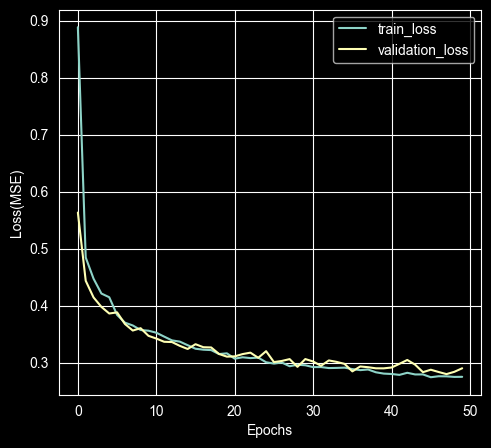

In [163]:
import matplotlib.pyplot as plt

# 학습 시각화 (loss, mae 그래프)
plt.figure(figsize=(12,5))

# 학습 / 검증 손실 그래프 생성
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='validation_loss')
plt.xlabel("Epochs")
plt.ylabel("Loss(MSE)")
plt.legend()

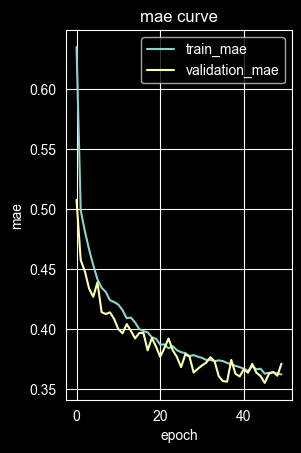

In [164]:
# 학습 / 검증 mae 그래프
plt.subplot(1,2,2)
plt.plot(history.history['mae'],label='train_mae')
plt.plot(history.history['val_mae'], label='validation_mae')
plt.title('mae curve')
plt.xlabel('epoch')
plt.ylabel('mae')
plt.legend()
plt.show()